In [43]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd

from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL

from mis_dro.bayes_conjugates import *
from mis_dro.main import run
from mis_dro.likelihood import sample_likelihood
from mis_dro.dataset import sample_dgp
from mis_dro.kl_divergence import *
from mis_dro.newsvendor import newsvendor_cost_cvxpy
from mis_dro.optimise import get_kl_bdro_problem
from mis_dro.plot import *


In [18]:
dgp = "normal"
dim = 1
num_likelihood_samples = 100
num_observations = 2
likelihood = "normal"
posterior = "normal_gamma"
generator = np.random.default_rng(seed=0)
data = sample_dgp(dgp, num_observations, generator=generator)
prior = default_prior_params(posterior)
post = get_posterior_params(posterior, data, prior)
pp_params = posterior_predictive_params(posterior, post)


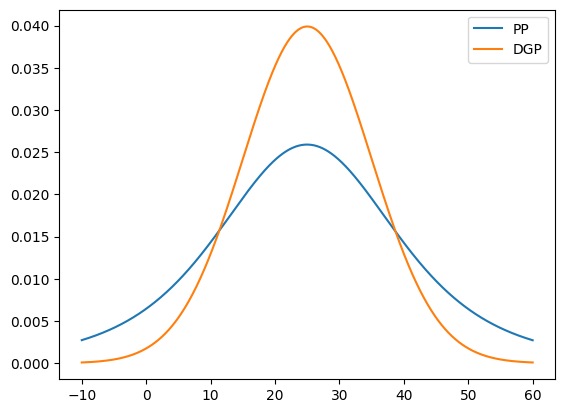

In [19]:
# plot the PDFs of the distributions
mu, scale, df = pp_params[0]
pp_dist = sp.stats.t(df, loc=mu, scale=scale)
DGP_NORMAL_MEAN = 25
dgp_dist = sp.stats.norm(loc=DGP_NORMAL_MEAN, scale=DGP_STD_TRUNCATED_NORMAL)
x = np.arange(DGP_NORMAL_MEAN - 35, DGP_NORMAL_MEAN + 35, 0.01)
plt.plot(x, pp_dist.pdf(x), label="PP")
plt.plot(x, dgp_dist.pdf(x), label="DGP")
plt.legend()

## Check that the approximations are close

In [20]:
kl_divergence_approx_histogram(
    dgp_dist.rvs(size=num_likelihood_samples, random_state=generator),
    pp_dist.rvs(size=num_likelihood_samples, random_state=generator),
    nbins=100
)

inf

In [21]:
kl_divergence_monte_carlo(dgp_dist, pp_dist, generator=generator)

0.1902349844963349

## Sanity check on 1D normal

Create two normal distributions. The KL can be computed in closed form. We compare our approximation to the MC approximation.

In [22]:
mu_1, std_1 = 25.0, 2.0
mu_2, std_2 = 24.8, 1.0

kl_divergence_1d_normals(mu_1, std_1, mu_2, std_2)

0.8268528194400546

In [23]:
normal_1 = sp.stats.norm(loc=mu_1, scale=std_1)
normal_2 = sp.stats.norm(loc=mu_2, scale=std_2)
kl_divergence_monte_carlo(normal_1, normal_2, generator=generator)

0.8348190342427981

In [38]:
def optimal_expected_kl(mu_dgp, std_dgp, mu_post, kappa_post, alpha_post, beta_post):
    dgp_precision = 1.0 / (std_dgp**2)
    return 0.5 * (
        np.log(beta_post * dgp_precision)
        + ((1/dgp_precision) + (mu_dgp - mu_post)**2) / (beta_post / alpha_post) 
        - 1 + 1.0/kappa_post - sp.special.digamma(alpha_post)
    ) 

## Now run PP and BAS using optimal epsilons

In [72]:
num_posterior_samples = 1
num_replications = 500
num_test_observations = 100
num_observations = 20
dim = 1
stats = []
for algorithm in ("kl_dro_bas", "kl_pp"):
    for num_likelihood_samples in [25, 100, 900]:
        problem = get_kl_bdro_problem(
            newsvendor_cost_cvxpy, num_posterior_samples, num_likelihood_samples, dim=dim,
        )
        for replication in range(num_replications):
            generator = np.random.default_rng(seed=replication)

            # DGP
            dgp_dist = sp.stats.norm(loc=DGP_NORMAL_MEAN, scale=DGP_STD_TRUNCATED_NORMAL)
            data = dgp_dist.rvs(size=num_observations, random_state=generator)
            data_eval = dgp_dist.rvs(size=num_test_observations, random_state=generator)

            # get posterior params
            prior = default_prior_params(posterior)
            theta_posterior = get_posterior_params(posterior, data, prior)

            if algorithm == "kl_pp": 
                # posterior predictive
                theta_sample = posterior_predictive_params(posterior, theta_posterior)
                mu, scale, df = theta_sample[0]
                pp_dist = sp.stats.t(df, loc=mu, scale=scale)
                
                # approximate optimal epsilon
                epsilon = kl_divergence_monte_carlo(dgp_dist, pp_dist, generator=generator)
                log_partition_constant = 0.0

                # sample posterior predictive
                xi = sample_posterior_predictive(likelihood, posterior, theta_sample, dim, num_likelihood_samples, generator=generator).reshape((1, num_likelihood_samples, dim))
            else:
                theta_sample = derive_analytical_posterior_params(posterior, theta_posterior)
                log_partition_constant = get_log_partition_constant(posterior, theta_posterior)
                mu_post, kappa_post, alpha_post, beta_post  = theta_posterior
                xi = sample_likelihood(
                    likelihood,
                    theta_sample,
                    dim,
                    num_likelihood_samples,
                    generator=generator,
                )
                epsilon = optimal_expected_kl(DGP_NORMAL_MEAN, DGP_STD_TRUNCATED_NORMAL, mu_post, kappa_post, alpha_post, beta_post)
                assert epsilon > log_partition_constant
            problem.param_dict["epsilon_minus_constant"].value = np.array([epsilon])
            for i in range(num_posterior_samples):
                problem.param_dict[f"xi_{i}"].value = xi[i]
            # NOTE the MOSEK 'accept_unknown' argument is needed due to https://github.com/cvxpy/cvxpy/pull/2117
            problem.solve(solver=cp.MOSEK, accept_unknown=True)
            solution = problem.var_dict["x"].value
            out_of_sample_cost = newsvendor_cost_cvxpy(solution, data_eval.reshape((num_test_observations, dim))).value

            stats.append({
                "algorithm": algorithm,
                "epsilon": epsilon,
                "replication": replication,
                "solution": solution,
                "out_of_sample_cost": list(out_of_sample_cost),
                "num_likelihood_samples": num_likelihood_samples,
                "log_partition_constant": log_partition_constant,
            })

/opt/anaconda3/envs/mis-dro/lib/python3.11/site-packages/cvxpy/problems/problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [76]:
stats_df = pd.DataFrame(stats)    
agg_df = stats_df.groupby(["algorithm", "num_likelihood_samples"]).agg(
    out_of_sample_mean = pd.NamedAgg(column="out_of_sample_cost", aggfunc=lambda x: np.mean(np.concatenate(x.values))),
    out_of_sample_var = pd.NamedAgg(column="out_of_sample_cost", aggfunc=lambda x: np.var(np.concatenate(x.values), ddof=1)),
    epsilon_mean = pd.NamedAgg(column="epsilon", aggfunc=np.mean),
    # epsilon_var = pd.NamedAgg(column="epsilon", aggfunc=np.var),
)
agg_df

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_88603/434959262.py:2: FutureWarning: The provided callable <function mean at 0x1051d20c0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = stats_df.groupby(["algorithm", "num_likelihood_samples"]).agg(


out_of_sample_mean  out_of_sample_var  \
algorithm  num_likelihood_samples                                          
kl_dro_bas 25                               39.060250         847.496652   
           100                              38.470482         796.911314   
           900                              38.227254         782.211221   
kl_pp      25                               39.038458         861.483385   
           100                              38.332504         805.748701   
           900                              38.258811         796.466269   

                                   epsilon_mean  
algorithm  num_likelihood_samples                
kl_dro_bas 25                          0.086342  
           100                         0.086342  
           900                         0.086342  
kl_pp      25                          0.044314  
           100                         0.044314  
           900                         0.044314

I've just got the "optimal epsilon" code working that we were discussing yesterday for 1D gaussian DGP. 

To summarise, for PP, we use MC to approximate the KL between a student T and the 